In [2]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp                         # pour utiliser sympy, on lui donne l'alias sp
from IPython.display import *              # pour utiliser display qui formate les équations
sp.init_printing(use_latex=True)           # pour utiliser LaTeX, formattage de grande qualité 
%matplotlib inline

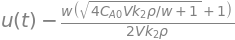

In [3]:
WA1,WA2,WA0,RAtot,t,Z=sp.symbols('W_A1,W_A2,W_A0,R_Atot,t,Z')
w,rho,CA0,k2,V=sp.symbols('w,rho,C_A0,k_2,V')
MAtot=sp.Function('M_Atot')(t)
CA=sp.Function('C_A')(t)

eq1=sp.Eq(V*sp.diff(CA,t),WA1-WA2-WA0+RAtot)
display(eq1)

#    WA1=(w/rho)*CA0
#    WA2=(w/rho)*CA
#    RAtot=-k2*CA**2*V

eq1=eq1.subs(WA1,(w/rho)*CA0).subs(WA2,(w/rho)*CA).subs(RAtot,-k2*CA**2*V)
diviseur=V
eq2=sp.Eq(eq1.lhs/diviseur,eq1.rhs/diviseur)
display(eq2)

# transformation suggérée

u=sp.Function('u')(t)
Z=sp.sqrt((4*rho*k2*CA0*V)/w+1)
#display(Z)
newCA=u-w/(2*rho*V*k2)*(1+Z)
display(newCA)
eq3=eq2.subs(CA,newCA).subs(WA0,0)
eq4=sp.Eq(eq3.lhs.simplify(),eq3.rhs.simplify())
display(eq4.simplify())

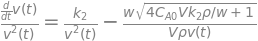

In [4]:
v=sp.Function('v')(t)
eq5=eq4.subs(u,1/v)
display(eq5.simplify())

In [5]:
diviseur=1/v**2
eq5=sp.Eq(eq5.lhs/diviseur,eq5.rhs/diviseur)
display(eq5.simplify())

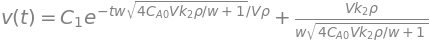

In [6]:
sol=sp.dsolve(eq5,v)
eq6=sp.Eq(v,sol.rhs)
eq6

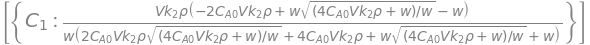

In [7]:
###
# je suis rendu ici, il faut poser v= 1/u en t=0 
#
eq7=sp.Eq(1/v,CA0+1/(2*k2)*(w/rho/V)*(1+Z))
eq7
### Donc on a que 1/eq6 en t=0 = eq7 donc on va faire 1/eq7.rhs
diviseur=eq7.rhs
CI=sp.Eq(eq6.rhs.subs(t,0),1/diviseur)
constante=sp.solve(CI,sp.symbols('C1'),dict=True)
display(constante)

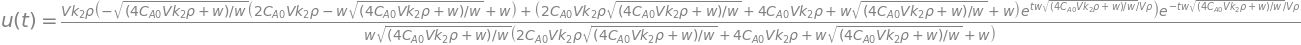

In [8]:
eq8=sp.Eq(u,eq6.rhs.subs(constante[0]))
eq8.simplify()